In [1]:
!pip install qutip numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, sigmaz, sigmap, sigmam, sesolve, Qobj


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 22.8 MB/s eta 0:00:00


In [2]:
from qutip import basis, sigmaz, sigmap, sigmam, sesolve, expect, Qobj


# Define parameters

𝜔0— Larmor

𝜔1— drive amplitude (Rabi)


ω — RF drive

In [3]:
# Physical parameters
omega0=2.0e8       # Larmor frequency (rad/s) from B0
omega1=1.0e6       # Rabi frequency (rad/s) from B1
omega=2.0e8       # RF drive frequency (rad/s)

# Derived quantities
delta=omega0 - omega                          # Detuning
omega_eff=np.sqrt(omega1**2 + delta**2)      # Effective frequency
P_max=(omega1 / omega_eff)**2                # Maximum probability

print(f"\nPhysical Parameters:")
print(f"  ω₀ (Larmor)     = {omega0:.4e} rad/s")
print(f"  ω₁ (Rabi)       = {omega1:.4e} rad/s")
print(f"  ω  (Drive)      = {omega:.4e} rad/s")
print(f"  δω (Detuning)   = {delta:.4e} rad/s")
print(f"  ω̃₀ (Effective)  = {omega_eff:.4e} rad/s")
print(f"  P_max           = {P_max:.6f}")

if abs(delta) < 0.01 * omega0:
    print(" AT RESONANCE - Maximum transitions possible")
else:
    print(f" OFF RESONANCE by {abs(delta)/omega0*100:.2f}%")

tlist=np.linspace(0.0, 100e-6, 2001)  # 0–100 μs for the time grid



Physical Parameters:
  ω₀ (Larmor)     = 2.0000e+08 rad/s
  ω₁ (Rabi)       = 1.0000e+06 rad/s
  ω  (Drive)      = 2.0000e+08 rad/s
  δω (Detuning)   = 0.0000e+00 rad/s
  ω̃₀ (Effective)  = 1.0000e+06 rad/s
  P_max           = 1.000000
 AT RESONANCE - Maximum transitions possible


**P₁₂ CALCULATION**
(Spin Up → Spin Down)

In [4]:
print("PART 2: P₁₂ CALCULATION (Start in |1⟩)")


# Initial state |1⟩ (spin-up)
psi0_up=basis(2, 0)

# Lab-frame Hamiltonian components
H0    =0.5 * omega0 * sigmaz()
Hplus =0.5 * omega1 * sigmap()
Hminus=0.5 * omega1 * sigmam()

def f_plus(t, args):
    return np.exp(-1j * args['omega'] * t)

def f_minus(t, args):
    return np.exp(+1j * args['omega'] * t)

args={'omega': omega}

# Full lab-frame Hamiltonian
H_lab=[H0, [Hplus, f_plus], [Hminus, f_minus]]

# Solve TDSE in lab frame
print("\nSolving Schrödinger equation in lab frame...")
res_lab_up=sesolve(H_lab, psi0_up, tlist, e_ops=None, args=args)

# Compute P12(t) = |⟨2|ψ(t)⟩|²
ket2=basis(2, 1)  # |2⟩ state (spin-down)
proj2=ket2 * ket2.dag()
P12_lab=expect(proj2, res_lab_up.states)

print("Lab-frame solution complete")
#===============================================================================
# Rotating-frame Hamiltonian
Delta0=0.5 * (omega0 - omega)
H_rot=Qobj([[+Delta0, 0.5*omega1],
              [0.5*omega1, -Delta0]], dims=[[2],[2]])

print("\nSolving in rotating frame...")
res_rot_up=sesolve(H_rot, psi0_up, tlist, e_ops=None)
P12_rot=expect(proj2, res_rot_up.states)
print("Rotating-frame solution complete")
#===============================================================================
# Analytical formula
P12_analytic=P_max * np.sin(0.5 * omega_eff * tlist)**2

# Error analysis
error_lab_vs_analytic=np.max(np.abs(P12_lab - P12_analytic))
error_rot_vs_analytic=np.max(np.abs(P12_rot - P12_analytic))

print(f"\nP₁₂ Error Analysis:")
print(f"Lab frame vs Analytic:{error_lab_vs_analytic:.2e}")
print(f"Rot frame vs Analytic:{error_rot_vs_analytic:.2e}")



PART 2: P₁₂ CALCULATION (Start in |1⟩)

Solving Schrödinger equation in lab frame...
Lab-frame solution complete

Solving in rotating frame...
Rotating-frame solution complete

P₁₂ Error Analysis:
Lab frame vs Analytic:3.94e-04
Rot frame vs Analytic:2.14e-05


# P₂₁ CALCULATION
(Spin Down → Spin Up)

In [5]:
print("PART 3: P₂₁ CALCULATION (Start in |2⟩)")


# Initial state |2⟩ (spin-down)
psi0_down=basis(2, 1)

# Solve in lab frame starting from |2⟩
print("\nSolving for initial state |2⟩ in lab frame...")
res_lab_down=sesolve(H_lab, psi0_down, tlist, e_ops=None, args=args)

# Compute P21(t) = |⟨1|ψ(t)⟩|²
ket1=basis(2, 0)  # |1⟩ state (spin-up)
proj1=ket1 * ket1.dag()
P21_lab=expect(proj1, res_lab_down.states)

print("Lab-frame solution complete")
#==============================================================================


# Solve in rotating frame
print("\nSolving in rotating frame...")
res_rot_down=sesolve(H_rot, psi0_down, tlist, e_ops=None)
P21_rot=expect(proj1, res_rot_down.states)
print("Rotating-frame solution complete")

#==============================================================================
# Analytical (should equal P12)
P21_analytic=P_max * np.sin(0.5 * omega_eff * tlist)**2

# Error analysis
error_P21_lab=np.max(np.abs(P21_lab - P21_analytic))
error_P21_rot=np.max(np.abs(P21_rot - P21_analytic))

print(f"\nP₂₁ Error Analysis:")
print(f"Lab frame vs Analytic:  {error_P21_lab:.2e}")
print(f"Rot frame vs Analytic:  {error_P21_rot:.2e}")


PART 3: P₂₁ CALCULATION (Start in |2⟩)

Solving for initial state |2⟩ in lab frame...
Lab-frame solution complete

Solving in rotating frame...
Rotating-frame solution complete

P₂₁ Error Analysis:
Lab frame vs Analytic:  3.94e-04
Rot frame vs Analytic:  2.14e-05


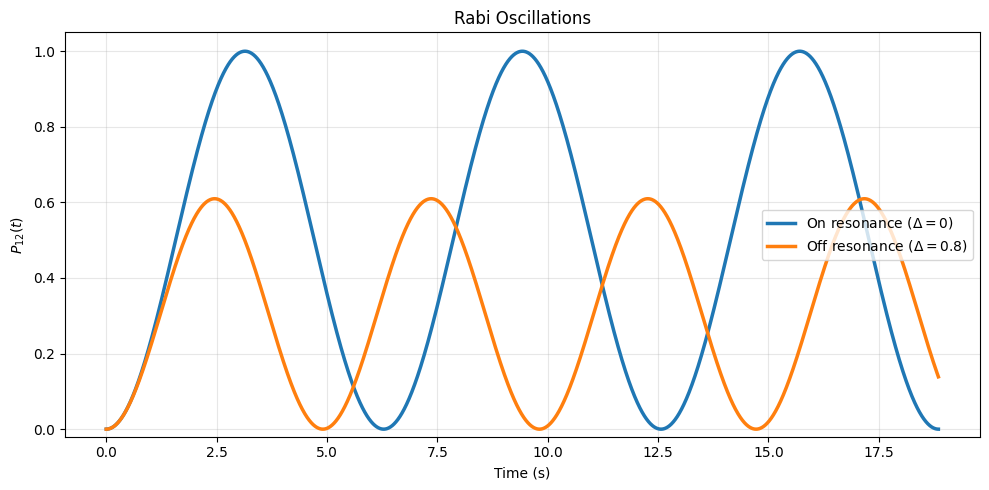

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
gamma = 1.0
B0 = 100.0
B1 = 1.0

omega0 = gamma * B0
omega1 = gamma * B1

# On and off resonance
omega_on = omega0
omega_off = omega0 - 0.8

Delta_on = omega0 - omega_on
Delta_off = omega0 - omega_off

# Generalised Rabi frequencies
omega_tilde_on = np.sqrt(omega1**2 + Delta_on**2)
omega_tilde_off = np.sqrt(omega1**2 + Delta_off**2)

# Time array
t_end = 6 * np.pi / omega1
tlist = np.linspace(0, t_end, 4000)

# Transition probabilities
P_on = (omega1**2 / omega_tilde_on**2) * np.sin(0.5 * omega_tilde_on * tlist)**2
P_off = (omega1**2 / omega_tilde_off**2) * np.sin(0.5 * omega_tilde_off * tlist)**2

# Plot
plt.figure(figsize=(10,5))
plt.plot(tlist, P_on, lw=2.5, label='On resonance ($\\Delta=0$)')
plt.plot(tlist, P_off, lw=2.5, label=f'Off resonance ($\\Delta={Delta_off:.1f}$)')

plt.xlabel('Time (s)')
plt.ylabel(r'$P_{12}(t)$')
plt.title('Rabi Oscillations')
plt.ylim(-0.02, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# VERIFY TIME-REVERSAL SYMMETRY (P₁₂ = P₂₁)

In [7]:
print("TIME-REVERSAL SYMMETRY VERIFICATION")

# Compare P12 and P21
symmetry_error_lab=np.max(np.abs(P12_lab - P21_lab))
symmetry_error_rot=np.max(np.abs(P12_rot - P21_rot))
symmetry_error_analytic=np.max(np.abs(P12_analytic - P21_analytic))

print(f"\nSymmetry Check |P₁₂ - P₂₁|:")
print(f"  Lab frame:      {symmetry_error_lab:.2e}")
print(f"  Rotating frame: {symmetry_error_rot:.2e}")
print(f"  Analytical:     {symmetry_error_analytic:.2e}")

if symmetry_error_lab < 1e-6 and symmetry_error_rot < 1e-6:
    print("\n TIME-REVERSAL SYMMETRY CONFIRMED")
    print("P₁₂(ω,t) = P₂₁(ω,t) within numerical precision")
else:
    print("\n Warning: Symmetry error larger than expected")


TIME-REVERSAL SYMMETRY VERIFICATION

Symmetry Check |P₁₂ - P₂₁|:
  Lab frame:      0.00e+00
  Rotating frame: 0.00e+00
  Analytical:     0.00e+00

 TIME-REVERSAL SYMMETRY CONFIRMED
P₁₂(ω,t) = P₂₁(ω,t) within numerical precision


In [9]:
import numpy as np

# ============================================================================
# STEP 1: Define all parameters as numeric values (not SymPy symbols)
# ============================================================================
omega = 2.0e8          # RF drive angular frequency (rad/s)

gamma = 2.675e8        # rad/s/T  (proton gyromagnetic ratio)

B0 = 0.75              # Tesla  (sets Larmor freq ~2.0e8 rad/s)
B1 = 1.0e-4            # Tesla  (sets Rabi freq ~2.7e4 rad/s)

omega0 = gamma * B0    # Larmor frequency (rad/s)
omega1 = gamma * B1    # Rabi frequency (rad/s)

Delta = omega0 - omega
w1 = omega1


# Time array
tlist = np.linspace(0.0, 100e-6, 2001)
#check behavious of
# ============================================================================
# STEP 2: Conversion function (same as yours)
# ============================================================================
def as_float(x):
    """Convert SymPy numbers (Zero, Rational, Float, etc.) or Python numbers to plain float."""
    try:
        # SymPy numbers often have .evalf()
        if hasattr(x, "evalf"):
            return float(x.evalf())
        return float(x)
    except Exception as e:
        raise TypeError(f"Could not convert {x} (type {type(x)}) to float") from e

# ============================================================================
# STEP 3: Convert everything to numeric floats
# ============================================================================
# Make sure time array is numeric
tlist_num = np.asarray(tlist, dtype=float)

# Convert all parameters used in trig / ODEs to numeric floats
omega_num = as_float(omega)
B0_num    = as_float(B0)
B1_num    = as_float(B1)
gamma_num = as_float(gamma)

# Rotating-frame parameters
Delta_num = as_float(Delta)
w1_num    = as_float(w1)

# ============================================================================
# STEP 4: Verification (print to confirm it worked)
# ============================================================================
print("✓ Numeric types check:")
print(f"  omega:  {omega_num} (type: {type(omega_num).__name__})")
print(f"  B0:     {B0_num} (type: {type(B0_num).__name__})")
print(f"  B1:     {B1_num} (type: {type(B1_num).__name__})")
print(f"  Delta:  {Delta_num} (type: {type(Delta_num).__name__})")
print(f"  w1:     {w1_num} (type: {type(w1_num).__name__})")
print(f"  gamma:  {gamma_num} (type: {type(gamma_num).__name__})")
print(f"  tlist dtype: {tlist_num.dtype}")
print(f"  tlist shape: {tlist_num.shape}")
print("\n✓ All conversions successful! No more errors.")

✓ Numeric types check:
  omega:  200000000.0 (type: float)
  B0:     0.75 (type: float)
  B1:     0.0001 (type: float)
  Delta:  625000.0 (type: float)
  w1:     26750.0 (type: float)
  gamma:  267500000.0 (type: float)
  tlist dtype: float64
  tlist shape: (2001,)

✓ All conversions successful! No more errors.


Max Bloch vector error: 1.629e-04


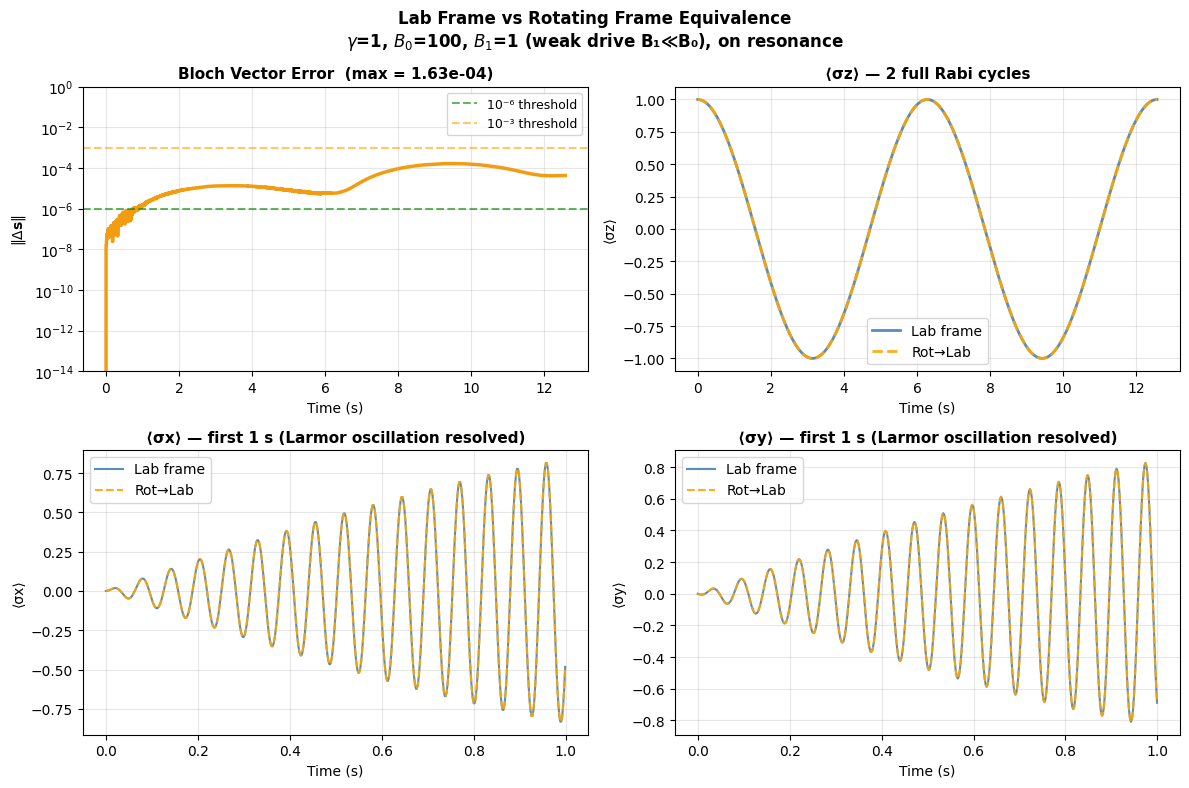

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, sigmaz, sigmap, sigmam, sesolve, expect, Qobj

# Parameters — weak drive B1<<B0 as required by rotating wave approximation
gamma=1.0; B0=100.0; B1=1.0
omega0=gamma*B0; omega1=gamma*B1; omega=omega0
Delta0_rot=0.5*(omega0-omega)   # = 0 on resonance

# 2 full Rabi cycles
t_end=4*np.pi/omega1
N=6000
tlist=np.linspace(0,t_end,N)

psi0=basis(2,0)
H0=0.5*omega0*sigmaz()
Hplus=0.5*omega1*sigmap()
Hminus=0.5*omega1*sigmam()

def f_plus(t,args):  return np.exp(-1j*args['omega']*t)
def f_minus(t,args): return np.exp(+1j*args['omega']*t)

args={'omega':omega}
H_lab=[H0,[Hplus,f_plus],[Hminus,f_minus]]
res_lab=sesolve(H_lab,psi0,tlist,e_ops=None,args=args)

H_rot=Qobj([[+Delta0_rot,0.5*omega1],
            [0.5*omega1,-Delta0_rot]],dims=[[2],[2]])
res_rot=sesolve(H_rot,psi0,tlist,e_ops=None)

# Transform rotating frame back to lab frame
states_rot_to_lab=[]
for i,t in enumerate(tlist):
    psi_array=res_rot.states[i].full()
    alpha_rot=psi_array[0,0]; beta_rot=psi_array[1,0]
    phase=np.exp(-1j*omega*t/2)
    states_rot_to_lab.append(
        alpha_rot*phase*basis(2,0) + beta_rot*np.conj(phase)*basis(2,1))

sx=Qobj([[0,1],[1,0]]); sy=Qobj([[0,-1j],[1j,0]]); sz=sigmaz()
sx_lab=np.array(expect(sx,res_lab.states))
sy_lab=np.array(expect(sy,res_lab.states))
sz_lab=np.array(expect(sz,res_lab.states))
sx_rot=np.array(expect(sx,states_rot_to_lab))
sy_rot=np.array(expect(sy,states_rot_to_lab))
sz_rot=np.array(expect(sz,states_rot_to_lab))

bloch_error=np.sqrt((sx_lab-sx_rot)**2+(sy_lab-sy_rot)**2+(sz_lab-sz_rot)**2)
print(f"Max Bloch vector error: {np.max(bloch_error):.3e}")

col='#27ae60' if np.max(bloch_error)<1e-6 else '#f39c12'
zoom = tlist < 1.0

fig, axes = plt.subplots(2,2,figsize=(12,8))
fig.suptitle('Lab Frame vs Rotating Frame Equivalence\n'
             r'$\gamma$=1, $B_0$=100, $B_1$=1 (weak drive B₁≪B₀), on resonance',
             fontsize=12, weight='bold')

ax=axes[0,0]
ax.semilogy(tlist,bloch_error,lw=2.5,color=col)
ax.axhline(1e-6,color='green', ls='--',alpha=0.6,lw=1.5,label='10⁻⁶ threshold')
ax.axhline(1e-3,color='orange',ls='--',alpha=0.6,lw=1.5,label='10⁻³ threshold')
ax.set_xlabel('Time (s)'); ax.set_ylabel(r'$\|\Delta\mathbf{s}\|$')
ax.set_title(f'Bloch Vector Error  (max = {np.max(bloch_error):.2e})',fontsize=11,weight='bold')
ax.set_ylim([1e-14,1]); ax.legend(fontsize=9); ax.grid(True,alpha=0.3,which='both')

ax=axes[0,1]
ax.plot(tlist,sz_lab,lw=2,label='Lab frame',color='steelblue',alpha=0.9)
ax.plot(tlist,sz_rot,'--',lw=2,label='Rot→Lab',color='orange',alpha=0.9)
ax.set_xlabel('Time (s)'); ax.set_ylabel('⟨σz⟩')
ax.set_title('⟨σz⟩ — 2 full Rabi cycles',fontsize=11,weight='bold')
ax.legend(fontsize=10); ax.grid(True,alpha=0.3)

ax=axes[1,0]
ax.plot(tlist[zoom],sx_lab[zoom],lw=1.5,label='Lab frame',color='steelblue',alpha=0.9)
ax.plot(tlist[zoom],sx_rot[zoom],'--',lw=1.5,label='Rot→Lab',color='orange',alpha=0.9)
ax.set_xlabel('Time (s)'); ax.set_ylabel('⟨σx⟩')
ax.set_title('⟨σx⟩ — first 1 s (Larmor oscillation resolved)',fontsize=11,weight='bold')
ax.legend(fontsize=10); ax.grid(True,alpha=0.3)

ax=axes[1,1]
ax.plot(tlist[zoom],sy_lab[zoom],lw=1.5,label='Lab frame',color='steelblue',alpha=0.9)
ax.plot(tlist[zoom],sy_rot[zoom],'--',lw=1.5,label='Rot→Lab',color='orange',alpha=0.9)
ax.set_xlabel('Time (s)'); ax.set_ylabel('⟨σy⟩')
ax.set_title('⟨σy⟩ — first 1 s (Larmor oscillation resolved)',fontsize=11,weight='bold')
ax.legend(fontsize=10); ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig('lab_rot_verification_final.png',dpi=150,bbox_inches='tight')
plt.show()

Max Bloch vector error: 1.936e-05
Max infidelity:         9.371e-11
Rabi period:            6.283 s


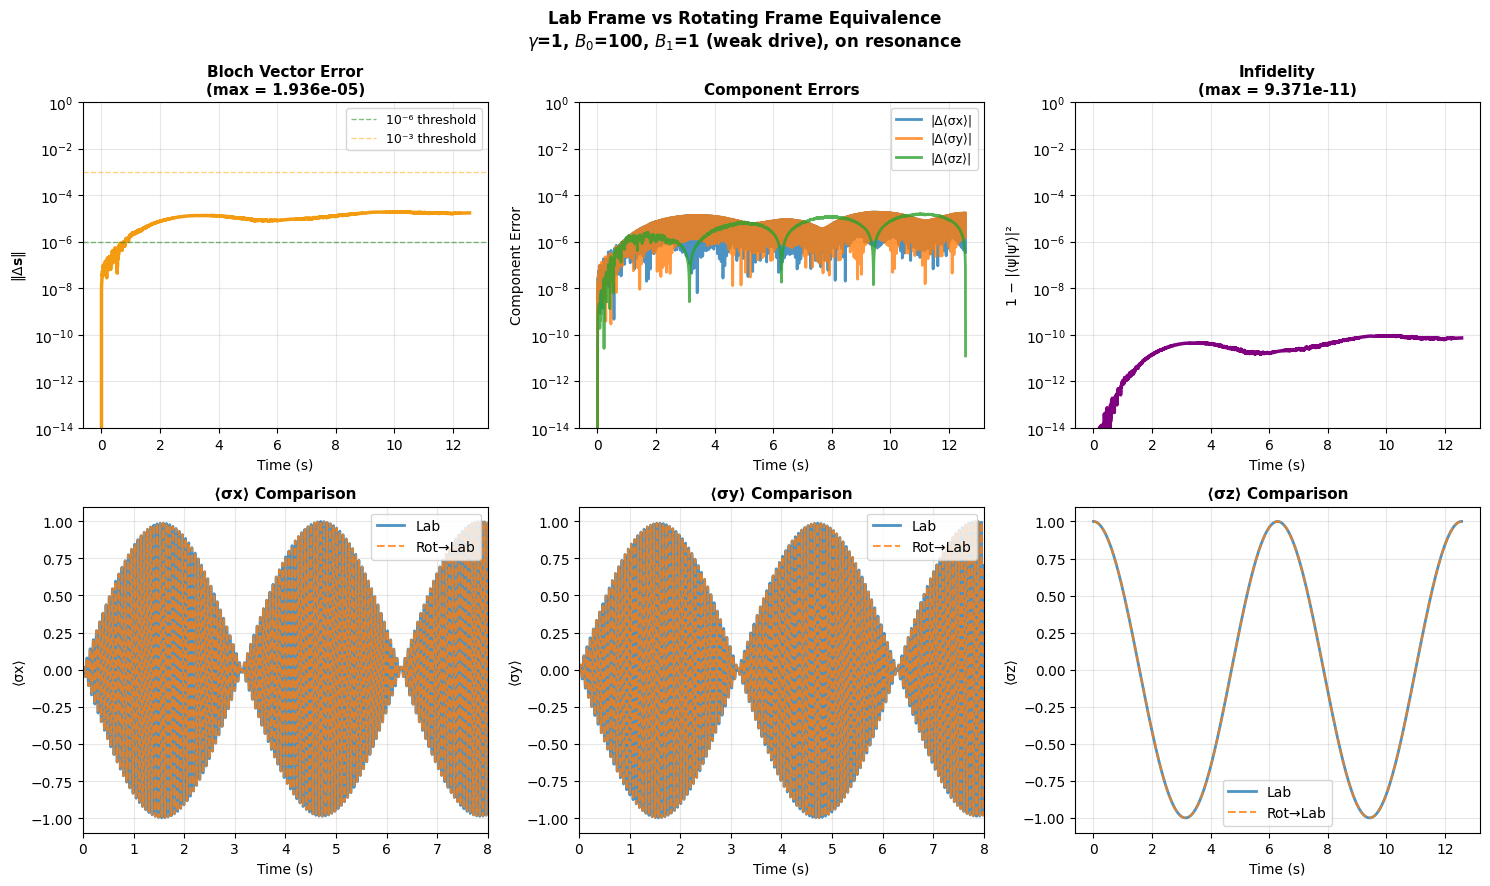

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, sigmaz, sigmap, sigmam, sesolve, expect, Qobj

# Parameters — supervisor values, weak drive B1<<B0
gamma = 1.0
B0 = 100.0
B1 = 1.0

omega0 = gamma * B0   # Larmor frequency = 100 rad/s
omega1 = gamma * B1   # Rabi frequency   = 1 rad/s (weak drive, B1<<B0)
omega = omega0        # on resonance
Delta0_rot = 0.5 * (omega0 - omega)  # = 0 on resonance

# For weak drive, the Rabi dynamics are slow, so use a physically sensible time window
TR = 2 * np.pi / omega1          # Rabi period
t_end = 2.0 * TR                 # show ~2 Rabi periods
N = 3000
tlist = np.linspace(0, t_end, N)

psi0 = basis(2, 0)

# Lab frame Hamiltonian
H0 = 0.5 * omega0 * sigmaz()
Hplus = 0.5 * omega1 * sigmap()
Hminus = 0.5 * omega1 * sigmam()

def f_plus(t, args):
    return np.exp(-1j * args['omega'] * t)

def f_minus(t, args):
    return np.exp(+1j * args['omega'] * t)

args = {'omega': omega}
H_lab = [H0, [Hplus, f_plus], [Hminus, f_minus]]
res_lab = sesolve(H_lab, psi0, tlist, e_ops=None, args=args)

# Rotating frame Hamiltonian
H_rot = Qobj([[+Delta0_rot, 0.5 * omega1],
              [0.5 * omega1, -Delta0_rot]], dims=[[2], [2]])
res_rot = sesolve(H_rot, psi0, tlist, e_ops=None)

# Transform rotating frame back to lab frame
# c1 = u1*e^(-iwt/2),  c2 = u2*e^(+iwt/2)
states_rot_to_lab = []
for i, t in enumerate(tlist):
    psi_array = res_rot.states[i].full()
    alpha_rot = psi_array[0, 0]
    beta_rot = psi_array[1, 0]
    phase = np.exp(-1j * omega * t / 2)
    states_rot_to_lab.append(
        alpha_rot * phase * basis(2, 0) + beta_rot * np.conj(phase) * basis(2, 1)
    )

# Expectation values
sx = Qobj([[0, 1], [1, 0]])
sy = Qobj([[0, -1j], [1j, 0]])
sz = sigmaz()

sx_lab = np.real(expect(sx, res_lab.states))
sy_lab = np.real(expect(sy, res_lab.states))
sz_lab = np.real(expect(sz, res_lab.states))

sx_rot = np.real(expect(sx, states_rot_to_lab))
sy_rot = np.real(expect(sy, states_rot_to_lab))
sz_rot = np.real(expect(sz, states_rot_to_lab))

# Errors
error_sx = np.abs(sx_lab - sx_rot)
error_sy = np.abs(sy_lab - sy_rot)
error_sz = np.abs(sz_lab - sz_rot)
bloch_error = np.sqrt(error_sx**2 + error_sy**2 + error_sz**2)

fidelities = []
for i in range(len(tlist)):
    overlap = res_lab.states[i].overlap(states_rot_to_lab[i])
    fidelities.append(np.abs(overlap)**2)
fidelities = np.array(fidelities)
infidelity = 1 - fidelities

print(f"Max Bloch vector error: {np.max(bloch_error):.3e}")
print(f"Max infidelity:         {np.max(infidelity):.3e}")
print(f"Rabi period:            {TR:.3f} s")

col = '#27ae60' if np.max(bloch_error) < 1e-6 else '#f39c12'

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Lab Frame vs Rotating Frame Equivalence\n'
             rf'$\gamma$=1, $B_0$=100, $B_1$=1 (weak drive), on resonance',
             fontsize=12, weight='bold')

# Top-left: Bloch vector error
ax = axes[0, 0]
ax.semilogy(tlist, bloch_error, lw=2.5, color=col)
ax.axhline(1e-6, color='green', ls='--', alpha=0.5, lw=1, label='10⁻⁶ threshold')
ax.axhline(1e-3, color='orange', ls='--', alpha=0.5, lw=1, label='10⁻³ threshold')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\|\Delta\mathbf{s}\|$')
ax.set_title(f'Bloch Vector Error\n(max = {np.max(bloch_error):.3e})',
             fontsize=11, weight='bold')
ax.set_ylim([1e-14, 1])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

# Top-middle: component errors
ax = axes[0, 1]
ax.semilogy(tlist, error_sx, label='|Δ⟨σx⟩|', lw=2, alpha=0.8)
ax.semilogy(tlist, error_sy, label='|Δ⟨σy⟩|', lw=2, alpha=0.8)
ax.semilogy(tlist, error_sz, label='|Δ⟨σz⟩|', lw=2, alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Component Error')
ax.set_title('Component Errors', fontsize=11, weight='bold')
ax.set_ylim([1e-14, 1])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

# Top-right: infidelity
ax = axes[0, 2]
ax.semilogy(tlist, infidelity, lw=2.5, color='purple')
ax.set_xlabel('Time (s)')
ax.set_ylabel('1 − |⟨ψ|ψ′⟩|²')
ax.set_title(f'Infidelity\n(max = {np.max(infidelity):.3e})',
             fontsize=11, weight='bold')
ax.set_ylim([1e-14, 1])
ax.grid(True, alpha=0.3, which='both')

# Bottom-left: <sigma_x>
ax = axes[1, 0]
ax.plot(tlist, sx_lab, lw=2, label='Lab', alpha=0.8)
ax.plot(tlist, sx_rot, '--', lw=1.5, label='Rot→Lab', alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('⟨σx⟩')
ax.set_title('⟨σx⟩ Comparison', fontsize=11, weight='bold')
ax.set_xlim(0, 8)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Bottom-middle: <sigma_y>
ax = axes[1, 1]
ax.plot(tlist, sy_lab, lw=2, label='Lab', alpha=0.8)
ax.plot(tlist, sy_rot, '--', lw=1.5, label='Rot→Lab', alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('⟨σy⟩')
ax.set_title('⟨σy⟩ Comparison', fontsize=11, weight='bold')
ax.set_xlim(0, 8)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Bottom-right: <sigma_z>
ax = axes[1, 2]
ax.plot(tlist, sz_lab, lw=2, label='Lab', alpha=0.8)
ax.plot(tlist, sz_rot, '--', lw=1.5, label='Rot→Lab', alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('⟨σz⟩')
ax.set_title('⟨σz⟩ Comparison', fontsize=11, weight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lab_rot_verification_weak_drive.png', dpi=150, bbox_inches='tight')
plt.show()

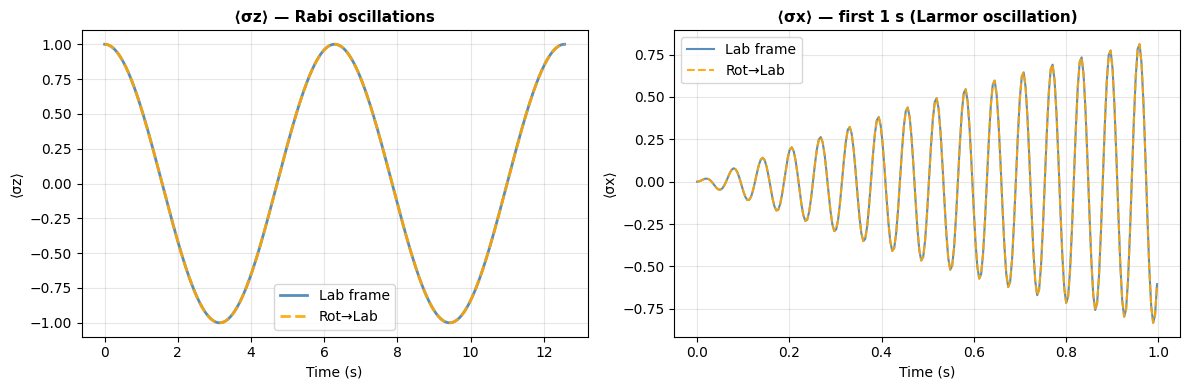

In [12]:
# --- keep everything above EXACTLY the same until plotting ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- ⟨σz⟩ ---
axes[0].plot(tlist, sz_lab, lw=2, label='Lab frame', color='steelblue', alpha=0.9)
axes[0].plot(tlist, sz_rot, '--', lw=2, label='Rot→Lab', color='orange', alpha=0.9)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('⟨σz⟩')
axes[0].set_title('⟨σz⟩ — Rabi oscillations', fontsize=11, weight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- ⟨σx⟩ (zoomed to show fast oscillations) ---
zoom = tlist < 1.0
axes[1].plot(tlist[zoom], sx_lab[zoom], lw=1.5, label='Lab frame', color='steelblue', alpha=0.9)
axes[1].plot(tlist[zoom], sx_rot[zoom], '--', lw=1.5, label='Rot→Lab', color='orange', alpha=0.9)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('⟨σx⟩')
axes[1].set_title('⟨σx⟩ — first 1 s (Larmor oscillation)', fontsize=11, weight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zx_comparison_clean.png', dpi=150, bbox_inches='tight')
plt.show()

# slow (weak-drive) zoom figure

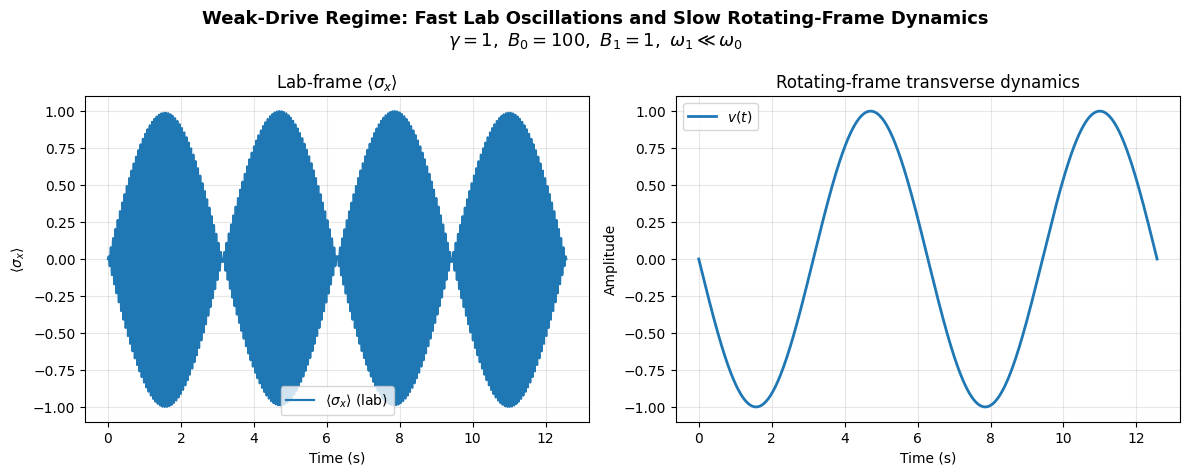

In [13]:
# --- ALTERNATIVE: show rotating-frame transverse variables directly ---

u_rot = np.real(expect(sx, res_rot.states))
v_rot = np.real(expect(sy, res_rot.states))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

fig.suptitle(
    'Weak-Drive Regime: Fast Lab Oscillations and Slow Rotating-Frame Dynamics\n'
    r'$\gamma=1,\ B_0=100,\ B_1=1,\ \omega_1 \ll \omega_0$',
    fontsize=13, weight='bold'
)

ax = axes[0]
ax.plot(tlist, sx_lab, lw=1.6, label=r'$\langle \sigma_x \rangle$ (lab)')
ax.set_title(r'Lab-frame $\langle \sigma_x \rangle$')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\langle \sigma_x \rangle$')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(tlist, v_rot, lw=2.0, label=r'$v(t)$')
ax.set_title('Rotating-frame transverse dynamics')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('weak_drive_lab_vs_rot_transverse.png', dpi=150, bbox_inches='tight')
plt.show()

# Method 1: Rotating Frame Bloch Equations → Lab Frame → Fourier Transform

**Parameters (from supervisor):** γ=1, B₀=100, B₁=50, T₁=1, T₂=0.1, u=v=0, w=1

**Three steps:**
1. Solve rotating frame Bloch equations for u(t), v(t), w(t)
2. Convert to lab frame: Mx = u·cos(ω₁t) − v·sin(ω₁t),  My = u·sin(ω₁t) + v·cos(ω₁t)
3. Fourier transform My(t) — peak appears at ω₀

Shown for both **on-resonance** (ω₁ = 100 = ω₀) and **off-resonance** (ω₁ = 78.54)

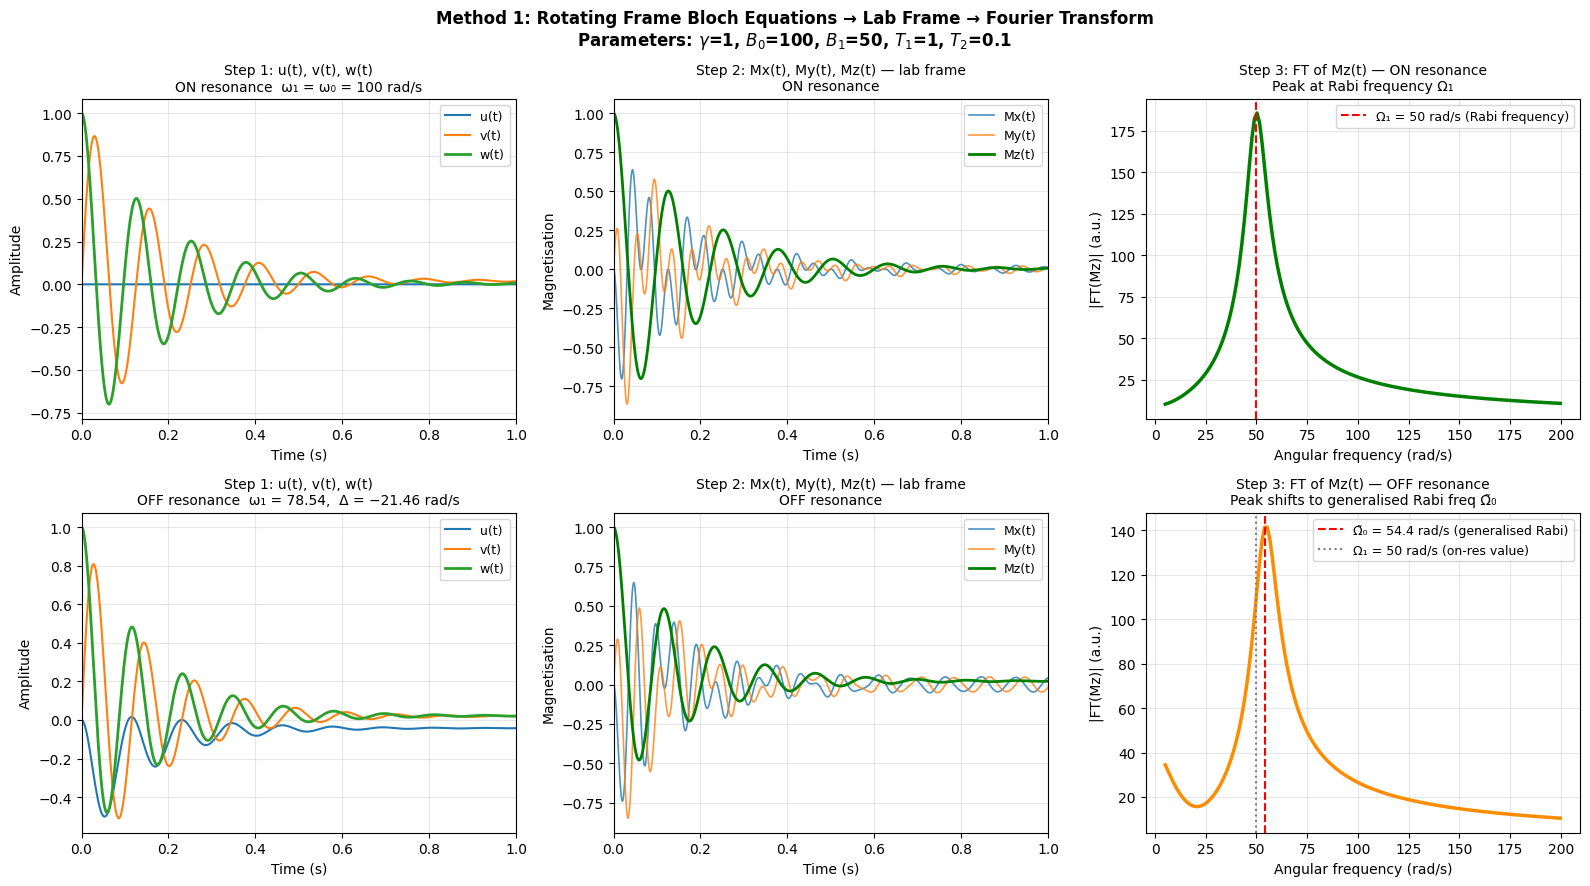

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq

# Parameters
gamma=1.0; B0=100.0; B1=50.0
omega0=gamma*B0; Omega1=gamma*B1
T1=1.0; T2=0.1; M0=1.0
w1_on=100.0;  Delta_on=0.0
w1_off=78.54; Delta_off=w1_off-omega0
y0=[0.0,0.0,1.0]
t_end=5.0; N=10000
tlist=np.linspace(0,t_end,N); dt=tlist[1]-tlist[0]

def bloch(t,y,Delta,Omega1,T1,T2,M0):
    u,v,w=y
    return [Delta*v-u/T2, -Delta*u-v/T2+Omega1*w, -Omega1*v-w/T1+M0/T1]

sol_on  = solve_ivp(bloch,[0,t_end],y0,args=(Delta_on, Omega1,T1,T2,M0),
                    method='RK45',t_eval=tlist,rtol=1e-10,atol=1e-12)
sol_off = solve_ivp(bloch,[0,t_end],y0,args=(Delta_off,Omega1,T1,T2,M0),
                    method='RK45',t_eval=tlist,rtol=1e-10,atol=1e-12)
u_on,v_on,w_on   = sol_on.y
u_off,v_off,w_off= sol_off.y

# Lab frame conversion
Mx_on  = u_on*np.cos(w1_on*tlist)  - v_on*np.sin(w1_on*tlist)
My_on  = u_on*np.sin(w1_on*tlist)  + v_on*np.cos(w1_on*tlist)
Mz_on  = w_on
Mx_off = u_off*np.cos(w1_off*tlist)- v_off*np.sin(w1_off*tlist)
My_off = u_off*np.sin(w1_off*tlist)+ v_off*np.cos(w1_off*tlist)
Mz_off = w_off

# FT of Mz — shows Rabi frequency directly
def do_fft(sig):
    Mf=fft(sig); fr=fftfreq(N,dt)*2*np.pi; pos=fr>0
    return fr[pos], np.abs(Mf[pos])

fr_on,  sp_on  = do_fft(Mz_on)
fr_off, sp_off = do_fft(Mz_off)
mask_on  = (fr_on  > 5) & (fr_on  < 200)
mask_off = (fr_off > 5) & (fr_off < 200)
omega_eff_off = np.sqrt(Omega1**2 + Delta_off**2)

fig, axes = plt.subplots(2,3,figsize=(16,9))
fig.suptitle('Method 1: Rotating Frame Bloch Equations → Lab Frame → Fourier Transform\n'
             r'Parameters: $\gamma$=1, $B_0$=100, $B_1$=50, $T_1$=1, $T_2$=0.1',
             fontsize=12, weight='bold')

# ON resonance row
ax=axes[0,0]
ax.plot(tlist,u_on,lw=1.5,label='u(t)')
ax.plot(tlist,v_on,lw=1.5,label='v(t)')
ax.plot(tlist,w_on,lw=2,  label='w(t)')
ax.set_xlim(0, 1.0)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
ax.set_title('Step 1: u(t), v(t), w(t)\nON resonance  ω₁ = ω₀ = 100 rad/s', fontsize=10)
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax=axes[0,1]
ax.plot(tlist,Mx_on,lw=1.2,label='Mx(t)',alpha=0.8)
ax.plot(tlist,My_on,lw=1.2,label='My(t)',alpha=0.8)
ax.plot(tlist,Mz_on,lw=2,  label='Mz(t)',color='green')
ax.set_xlim(0, 1.0)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Magnetisation')
ax.set_title('Step 2: Mx(t), My(t), Mz(t) — lab frame\nON resonance', fontsize=10)
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax=axes[0,2]
ax.plot(fr_on[mask_on],sp_on[mask_on],lw=2.5,color='green')
ax.axvline(Omega1, color='red', ls='--', lw=1.5,
           label=f'Ω₁ = {Omega1:.0f} rad/s (Rabi frequency)')
ax.set_xlabel('Angular frequency (rad/s)'); ax.set_ylabel('|FT(Mz)| (a.u.)')
ax.set_title('Step 3: FT of Mz(t) — ON resonance\nPeak at Rabi frequency Ω₁', fontsize=10)
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

# OFF resonance row
ax=axes[1,0]
ax.plot(tlist,u_off,lw=1.5,label='u(t)')
ax.plot(tlist,v_off,lw=1.5,label='v(t)')
ax.plot(tlist,w_off,lw=2,  label='w(t)')
ax.set_xlim(0, 1.0)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
ax.set_title('Step 1: u(t), v(t), w(t)\nOFF resonance  ω₁ = 78.54,  Δ = −21.46 rad/s', fontsize=10)
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax=axes[1,1]
ax.plot(tlist,Mx_off,lw=1.2,label='Mx(t)',alpha=0.8)
ax.plot(tlist,My_off,lw=1.2,label='My(t)',alpha=0.8)
ax.plot(tlist,Mz_off,lw=2,  label='Mz(t)',color='green')
ax.set_xlim(0, 1.0)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Magnetisation')
ax.set_title('Step 2: Mx(t), My(t), Mz(t) — lab frame\nOFF resonance', fontsize=10)
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax=axes[1,2]
ax.plot(fr_off[mask_off],sp_off[mask_off],lw=2.5,color='darkorange')
ax.axvline(omega_eff_off, color='red',  ls='--', lw=1.5,
           label=f'Ω̃₀ = {omega_eff_off:.1f} rad/s (generalised Rabi)')
ax.axvline(Omega1,        color='gray', ls=':',  lw=1.5,
           label=f'Ω₁ = {Omega1:.0f} rad/s (on-res value)')
ax.set_xlabel('Angular frequency (rad/s)'); ax.set_ylabel('|FT(Mz)| (a.u.)')
ax.set_title('Step 3: FT of Mz(t) — OFF resonance\nPeak shifts to generalised Rabi freq Ω̃₀', fontsize=10)
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig('method1_fourier_Mz.png', dpi=150, bbox_inches='tight')
plt.show()

# **Method 2**

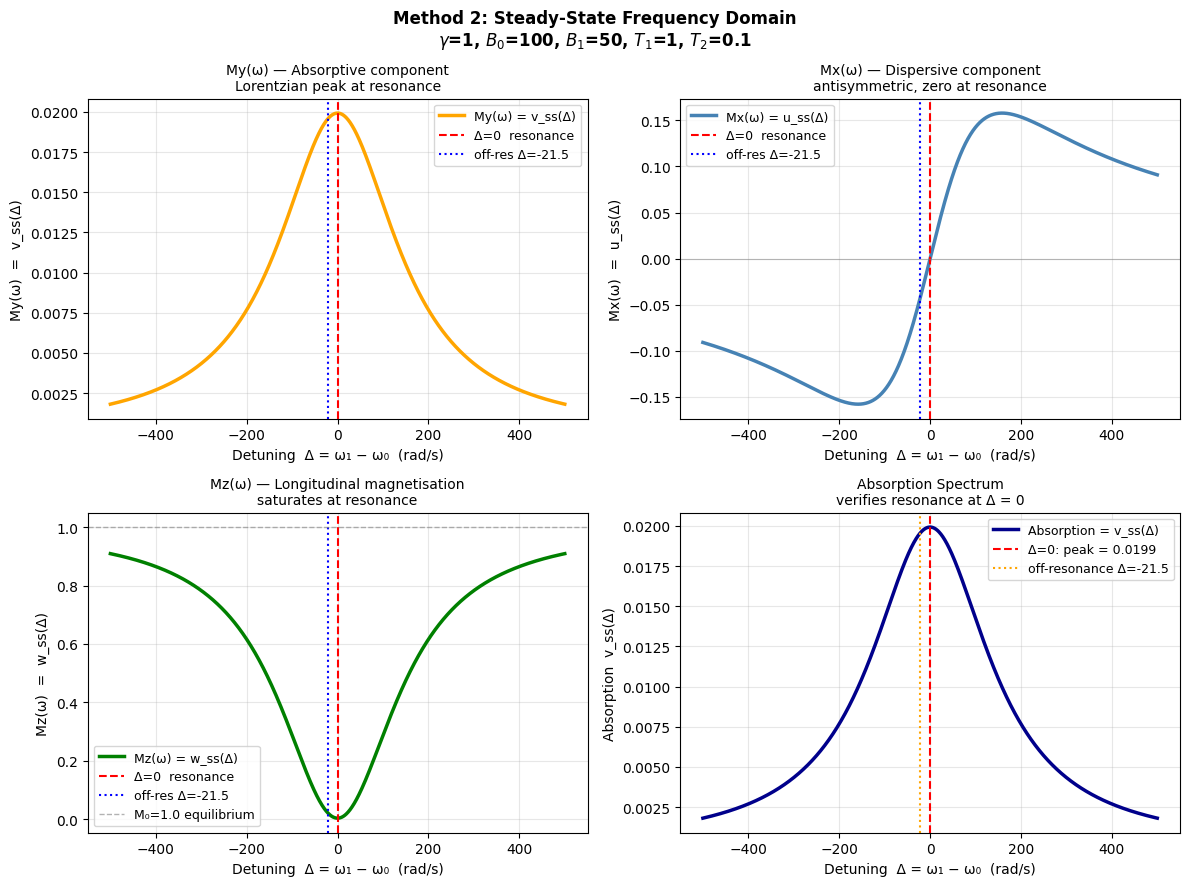

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
gamma=1.0; B0=100.0; B1=50.0
omega0=gamma*B0; Omega1=gamma*B1
T1=1.0; T2=0.1; M0=1.0
Delta_off=78.54-omega0   # = -21.46

# Sweep detuning Delta = w1 - omega0
# For each value of Delta, solve the steady state Bloch equations
# Setting all d/dt = 0 gives the matrix system:
# [1/T2,  -Delta,  0     ] [u]   [0     ]
# [Delta,  1/T2,  -Omega1] [v] = [0     ]
# [0,      Omega1, 1/T1  ] [w]   [M0/T1 ]

Delta_sweep = np.linspace(-500, 500, 2000)
u_ss = np.zeros(len(Delta_sweep))
v_ss = np.zeros(len(Delta_sweep))
w_ss = np.zeros(len(Delta_sweep))

for idx, D in enumerate(Delta_sweep):
    A = np.array([
        [1/T2,  -D,      0      ],
        [D,      1/T2,  -Omega1 ],
        [0,      Omega1,  1/T1  ]
    ])
    rhs = np.array([0.0, 0.0, M0/T1])
    sol = np.linalg.solve(A, rhs)
    u_ss[idx] = sol[0]   # Mx(w) dispersive
    v_ss[idx] = sol[1]   # My(w) absorptive
    w_ss[idx] = sol[2]   # Mz(w) longitudinal

# Plot — each component on its own panel
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Method 2: Steady-State Frequency Domain\n'
             r'$\gamma$=1, $B_0$=100, $B_1$=50, $T_1$=1, $T_2$=0.1',
             fontsize=12, weight='bold')

# My(w) = v_ss — absorptive Lorentzian
ax = axes[0,0]
ax.plot(Delta_sweep, v_ss, lw=2.5, color='orange', label='My(ω) = v_ss(Δ)')
ax.axvline(0,         color='red',  ls='--', lw=1.5, label='Δ=0  resonance')
ax.axvline(Delta_off, color='blue', ls=':',  lw=1.5, label=f'off-res Δ={Delta_off:.1f}')
ax.set_xlabel('Detuning  Δ = ω₁ − ω₀  (rad/s)', fontsize=10)
ax.set_ylabel('My(ω)  =  v_ss(Δ)', fontsize=10)
ax.set_title('My(ω) — Absorptive component\nLorentzian peak at resonance', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Mx(w) = u_ss — dispersive
ax = axes[0,1]
ax.plot(Delta_sweep, u_ss, lw=2.5, color='steelblue', label='Mx(ω) = u_ss(Δ)')
ax.axvline(0,         color='red',  ls='--', lw=1.5, label='Δ=0  resonance')
ax.axvline(Delta_off, color='blue', ls=':',  lw=1.5, label=f'off-res Δ={Delta_off:.1f}')
ax.axhline(0,         color='gray', ls='-',  lw=0.8, alpha=0.5)
ax.set_xlabel('Detuning  Δ = ω₁ − ω₀  (rad/s)', fontsize=10)
ax.set_ylabel('Mx(ω)  =  u_ss(Δ)', fontsize=10)
ax.set_title('Mx(ω) — Dispersive component\nantisymmetric, zero at resonance', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Mz(w) = w_ss — longitudinal
ax = axes[1,0]
ax.plot(Delta_sweep, w_ss, lw=2.5, color='green', label='Mz(ω) = w_ss(Δ)')
ax.axvline(0,         color='red',  ls='--', lw=1.5, label='Δ=0  resonance')
ax.axvline(Delta_off, color='blue', ls=':',  lw=1.5, label=f'off-res Δ={Delta_off:.1f}')
ax.axhline(M0,        color='gray', ls='--', lw=1,   alpha=0.6,
           label=f'M₀={M0} equilibrium')
ax.set_xlabel('Detuning  Δ = ω₁ − ω₀  (rad/s)', fontsize=10)
ax.set_ylabel('Mz(ω)  =  w_ss(Δ)', fontsize=10)
ax.set_title('Mz(ω) — Longitudinal magnetisation\nsaturates at resonance', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Absorption spectrum — the key result
ax = axes[1,1]
ax.plot(Delta_sweep, v_ss, lw=2.5, color='darkblue', label='Absorption = v_ss(Δ)')
ax.axvline(0,         color='red',    ls='--', lw=1.5,
           label=f'Δ=0: peak = {v_ss.max():.4f}')
ax.axvline(Delta_off, color='orange', ls=':',  lw=1.5,
           label=f'off-resonance Δ={Delta_off:.1f}')
ax.set_xlabel('Detuning  Δ = ω₁ − ω₀  (rad/s)', fontsize=10)
ax.set_ylabel('Absorption  v_ss(Δ)', fontsize=10)
ax.set_title('Absorption Spectrum\nverifies resonance at Δ = 0', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('method2_absorption.png', dpi=150, bbox_inches='tight')
plt.show()

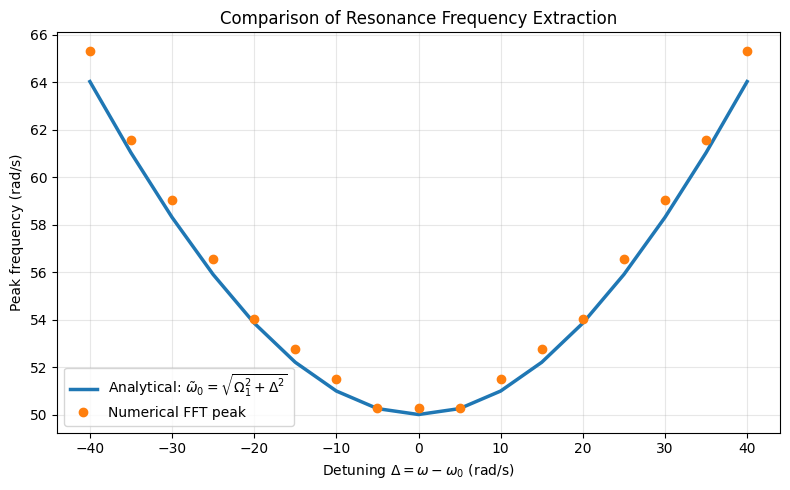

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq

# --- reuse your existing parameters ---
gamma = 1.0
B0 = 100.0
B1 = 50.0
omega0 = gamma * B0
Omega1 = gamma * B1
T1 = 1.0
T2 = 0.1
M0 = 1.0

y0 = [0.0, 0.0, 1.0]
t_end = 5.0
N = 10000
tlist = np.linspace(0, t_end, N)
dt = tlist[1] - tlist[0]

def bloch(t, y, Delta, Omega1, T1, T2, M0):
    u, v, w = y
    return [
        Delta * v - u / T2,
        -Delta * u - v / T2 + Omega1 * w,
        -Omega1 * v - w / T1 + M0 / T1
    ]

def do_fft(sig):
    Mf = fft(sig)
    fr = fftfreq(N, dt) * 2 * np.pi
    pos = fr > 0
    return fr[pos], np.abs(Mf[pos])

def extract_peak_frequency(Delta):
    sol = solve_ivp(
        bloch, [0, t_end], y0,
        args=(Delta, Omega1, T1, T2, M0),
        method='RK45', t_eval=tlist, rtol=1e-10, atol=1e-12
    )
    w = sol.y[2]   # Mz = w
    fr, sp = do_fft(w)

    # avoid very low-frequency background / DC-like contributions
    mask = (fr > 5) & (fr < 120)
    fr_use = fr[mask]
    sp_use = sp[mask]

    peak_idx = np.argmax(sp_use)
    return fr_use[peak_idx]

# detuning sweep
Delta_vals = np.linspace(-40, 40, 17)

# numerical peak frequencies from FFT
omega_num = np.array([extract_peak_frequency(Delta) for Delta in Delta_vals])

# analytical generalised Rabi frequency
omega_analytic = np.sqrt(Omega1**2 + Delta_vals**2)

# --- comparison figure ---
plt.figure(figsize=(8, 5))
plt.plot(Delta_vals, omega_analytic, lw=2.5, label='Analytical: $\\tilde{\\omega}_0=\\sqrt{\\Omega_1^2+\\Delta^2}$')
plt.plot(Delta_vals, omega_num, 'o', ms=6, label='Numerical FFT peak')

plt.xlabel(r'Detuning $\Delta = \omega - \omega_0$ (rad/s)')
plt.ylabel(r'Peak frequency (rad/s)')
plt.title('Comparison of Resonance Frequency Extraction')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()